In [1]:
# ============================================================
# 1. SETUP, DATA, SPLIT, FEATURES
# ============================================================
import os
os.environ["TABPFN_MAX_BATCHED_TEST_ROWS"] = "1000"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

import numpy as np, pandas as pd, matplotlib.pyplot as plt
from itertools import combinations
from sklearn.datasets import fetch_openml
from sklearn.metrics import mean_poisson_deviance
from sklearn.ensemble import HistGradientBoostingRegressor
from glum import GeneralizedLinearRegressor
from tabpfn import TabPFNClassifier

BLUE, ORANGE, GREY = "#2a78d6", "#eb6834", "#7a7a7a"
SEED = 42

# ---- data: freMTPL2freq from OpenML, with the standard cleaning ----
df = fetch_openml(data_id=41214, as_frame=True).frame
df["ClaimNb"]  = df["ClaimNb"].clip(upper=4)        # a few rows carry implausible counts
df["Exposure"] = df["Exposure"].clip(upper=1)       # a few rows exceed one year
CATS    = ["Area", "VehBrand", "VehGas", "Region"]
FACTORS = ["Area", "VehPower", "VehAge", "DrivAge", "BonusMalus", "VehBrand", "VehGas", "Density", "Region"]
for c in CATS:
    df[c] = df[c].astype("category")

# ---- split: decided once, never touched again ----
u = np.random.default_rng(SEED).random(len(df))
train      = df[u < .55].copy()                   # every model learns here, and only here
validation = df[(u >= .55) & (u < .80)].copy()    # models are compared here; recommendations come from here
test       = df[u >= .80].copy()                  # locked until the end; used only to score GLM refits

# ---- features ----
# (a) the tutorial GLM's feature engineering (Noll, Salzmann & Wüthrich; actuarial-data-science notebook)
# (b) fine decile bands on the two ages, used only to lay out diagnostic tables
EDGES = {c: np.quantile(train[c], np.linspace(0, 1, 11)) for c in ["DrivAge", "VehAge"]}
for e in EDGES.values(): e[0], e[-1] = -np.inf, np.inf

def add_features(part):
    part = part.copy()
    part["VehPowerC"]  = np.minimum(part.VehPower, 9).astype(str)                                        # 4..8, 9+
    part["VehAgeC"]    = pd.cut(part.VehAge,  [-np.inf, 1, 11, np.inf], right=False).astype(str)          # 0 | 1-10 | 11+
    part["DrivAgeC"]   = pd.cut(part.DrivAge, [-np.inf, 21, 26, 31, 41, 51, 71, np.inf], right=False).astype(str)
    part["BMcap"]      = np.minimum(part.BonusMalus, 150)
    part["AreaN"]      = part.Area.astype(str).str.strip("'").map({"A": 1, "B": 2, "C": 3, "D": 4, "E": 5, "F": 6})
    part["LogDensity"] = np.log(part.Density)
    for c, e in EDGES.items():
        part[c + "Band"] = pd.cut(part[c], bins=np.unique(e), right=False)
    return part

train, validation, test = add_features(train), add_features(validation), add_features(test)

for name, part in [("train", train), ("validation", validation), ("test", test)]:
    print(f"{name:11s} rows={len(part):7d}  exposure={part.Exposure.sum():9.0f}  claims={part.ClaimNb.sum():6.0f}  "
          f"frequency={part.ClaimNb.sum() / part.Exposure.sum():.4f}")

c:\Users\igode\Desktop\lqm\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


train       rows= 373336  exposure=   197322  claims= 19899  frequency=0.1008
validation  rows= 169259  exposure=    89551  claims=  8978  frequency=0.1003
test        rows= 135418  exposure=    71488  claims=  7179  frequency=0.1004


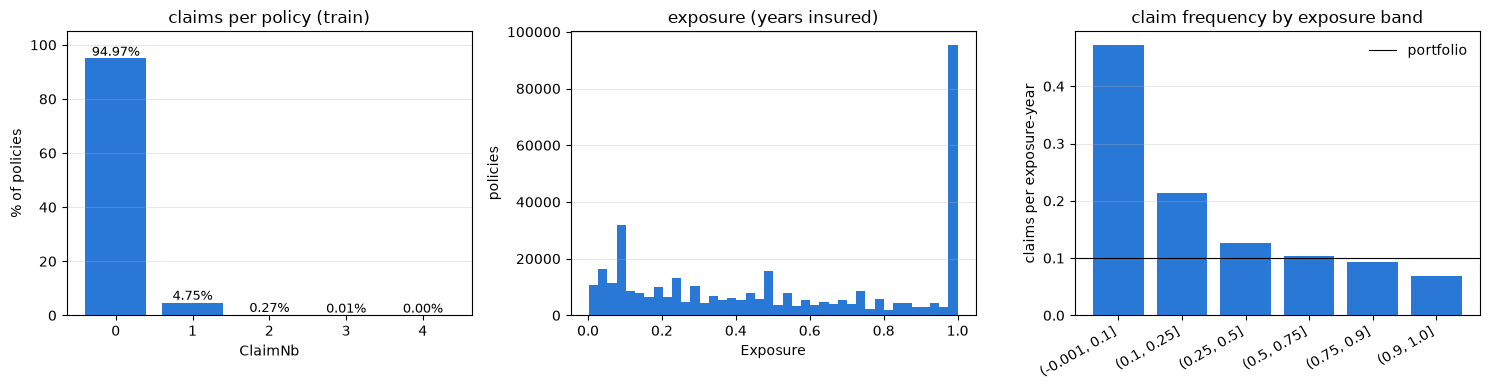

policies with any claim: 5.03%   of those, exactly one claim: 94.4%


In [2]:
# ============================================================
# 2. WHAT THE DATA LOOKS LIKE
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) the target: almost all zeros
cnt = train.ClaimNb.value_counts().sort_index()
axes[0].bar(cnt.index, cnt.values / cnt.sum() * 100, color=BLUE)
for k, v in zip(cnt.index, cnt.values / cnt.sum() * 100):
    axes[0].text(k, v + 1, f"{v:.2f}%", ha="center", fontsize=9)
axes[0].set_title("claims per policy (train)"); axes[0].set_xlabel("ClaimNb"); axes[0].set_ylabel("% of policies")
axes[0].set_ylim(0, 105); axes[0].grid(axis="y", alpha=.3)

# (b) exposure: most policies are not on the books for a full year
axes[1].hist(train.Exposure, bins=40, color=BLUE)
axes[1].set_title("exposure (years insured)"); axes[1].set_xlabel("Exposure"); axes[1].set_ylabel("policies"); axes[1].grid(axis="y", alpha=.3)

# (c) the exposure artefact: short policies show higher frequency
eb = pd.cut(train.Exposure, [0, .1, .25, .5, .75, .9, 1.0], include_lowest=True)
fr = train.groupby(eb, observed=True).apply(lambda d: d.ClaimNb.sum() / d.Exposure.sum())
axes[2].bar(range(len(fr)), fr.values, color=BLUE)
axes[2].set_xticks(range(len(fr))); axes[2].set_xticklabels([str(i) for i in fr.index], rotation=30, ha="right")
axes[2].axhline(train.ClaimNb.sum() / train.Exposure.sum(), color="k", lw=.8, label="portfolio")
axes[2].set_title("claim frequency by exposure band"); axes[2].set_ylabel("claims per exposure-year"); axes[2].legend(frameon=False); axes[2].grid(axis="y", alpha=.3)
plt.tight_layout(); plt.show()

print(f"policies with any claim: {(train.ClaimNb > 0).mean():.2%}   of those, exactly one claim: {(train.ClaimNb[train.ClaimNb > 0] == 1).mean():.1%}")

In [3]:
# ============================================================
# 3. SCORING
# ============================================================
base_rate = train.ClaimNb.sum() / train.Exposure.sum()

def d2(counts, part):
    """Poisson deviance explained vs. the mean model (charge everyone the portfolio frequency)."""
    y = part.ClaimNb.values
    return 1 - mean_poisson_deviance(y, np.clip(counts, 1e-6, None)) / mean_poisson_deviance(y, part.Exposure.values * base_rate)

def dev(counts, part):
    return mean_poisson_deviance(part.ClaimNb.values, np.clip(counts, 1e-6, None))

def gini(counts, part, seed=0):
    y, w = part.ClaimNb.values, part.Exposure.values
    perm = np.random.default_rng(seed).permutation(len(y))
    order = perm[np.argsort((np.asarray(counts) / w)[perm], kind="stable")]
    cum_w, cum_y = np.cumsum(w[order]) / w.sum(), np.cumsum(y[order]) / y.sum()
    return 1 - 2 * np.trapezoid(cum_y, cum_w)

def paired_bootstrap(pred_a, pred_b, part, n=500, seed=0):
    """Distribution of the D2 gain of b over a, resampling policies."""
    rng, y = np.random.default_rng(seed), part.ClaimNb.values
    a, b, m = np.asarray(pred_a), np.asarray(pred_b), part.Exposure.values * base_rate
    gains = []
    for _ in range(n):
        i = rng.integers(0, len(y), len(y))
        dm = mean_poisson_deviance(y[i], m[i])
        gains.append((mean_poisson_deviance(y[i], a[i]) - mean_poisson_deviance(y[i], b[i])) / dm * 100)
    return np.mean(gains), np.percentile(gains, 2.5), np.percentile(gains, 97.5)

def report(name, counts, part=None):
    part = test if part is None else part
    print(f"{name:34s} D2 {d2(counts, part):6.2%}   Gini {gini(counts, part):.3f}   deviance {dev(counts, part):.4f}   "
          f"predicted {np.sum(counts):6.0f}  (actual {part.ClaimNb.sum()})")

In [4]:
# ============================================================
# 4. THE BASELINE GLM (tutorial specification) AND A GBM CEILING
# ============================================================
FORMULA0 = "C(VehPowerC) + C(VehAgeC) + C(DrivAgeC) + BMcap + C(VehBrand) + C(VehGas) + LogDensity + C(Region) + AreaN"

def fit_glm(formula, data):
    return GeneralizedLinearRegressor(family="poisson", alpha=0, formula=formula, drop_first=True
                                      ).fit(data, data.ClaimNb, offset=np.log(data.Exposure))
def glm_counts(g, part):
    return np.asarray(g.predict(part, offset=np.log(part.Exposure)))

glm0 = fit_glm(FORMULA0, train)

# a flexible model on the same nine factors: how much structure is there that a GLM's shape could miss?
gbm = HistGradientBoostingRegressor(loss="poisson", max_iter=300, learning_rate=0.05,
                                    categorical_features="from_dtype", random_state=0)
gbm.fit(train[FACTORS], train.ClaimNb / train.Exposure, sample_weight=train.Exposure)
gbm_counts = lambda part: gbm.predict(part[FACTORS]) * part.Exposure.values

report("mean model",              test.Exposure.values * base_rate)
report("GLM0  (tutorial spec)",   glm_counts(glm0, test))
report("GBM   (ceiling)",         gbm_counts(test))
print(f"\nGLM0 has {len(glm0.coef_)} parameters")

mean model                         D2  0.00%   Gini -0.011   deviance 0.3261   predicted   7209  (actual 7179)
GLM0  (tutorial spec)              D2  5.01%   Gini 0.276   deviance 0.3098   predicted   7253  (actual 7179)
GBM   (ceiling)                    D2  8.19%   Gini 0.325   deviance 0.2994   predicted   7224  (actual 7179)

GLM0 has 48 parameters


In [5]:
# ============================================================
# 5. THE INFORMANT: a TabPFN classifier, recalibrated
# ============================================================
LQM_INPUTS = FACTORS + ["Exposure"]
def lqm_inputs(part):
    X = part[LQM_INPUTS].copy()
    for c in CATS: X[c] = X[c].cat.codes
    return X

# context (what the model learns from) and calibration rows (never in its context), both from train
ctx   = train.groupby(train.ClaimNb > 0, group_keys=False).sample(frac=100_000 / len(train), random_state=0)
calib = train.drop(ctx.index).sample(80_000, random_state=0)
k2    = ctx.loc[ctx.ClaimNb >= 2, "ClaimNb"].mean()                  # average count among 2+ rows

def lqm_fit():
    m = TabPFNClassifier(device="cuda", random_state=0, fit_mode="fit_with_cache", n_estimators=4)
    return m.fit(lqm_inputs(ctx), np.minimum(ctx.ClaimNb.values, 2))   # classes: 0 / 1 / 2+

def lqm_raw(m, part, chunk=5000):
    """Raw expected claims: P(1) + k2 * P(2+), at the policy's actual exposure."""
    X = lqm_inputs(part)
    P = np.vstack([m.predict_proba(X.iloc[i:i + chunk]) for i in range(0, len(X), chunk)])
    return P[:, 1] + k2 * P[:, 2]

# ---- predict once, cache to disk ----
CACHE = {"calib": "lqm_raw_calib.parquet", "validation": "lqm_raw_validation.parquet"}
if all(os.path.exists(f) for f in CACHE.values()):
    raw_cal = pd.read_parquet(CACHE["calib"]).loc[calib.index, "raw"].values
    raw_val = pd.read_parquet(CACHE["validation"]).loc[validation.index, "raw"].values
    print("loaded cached LQM predictions")
else:
    lqm = lqm_fit()
    raw_cal = lqm_raw(lqm, calib);      pd.DataFrame({"raw": raw_cal}, index=calib.index).to_parquet(CACHE["calib"])
    raw_val = lqm_raw(lqm, validation); pd.DataFrame({"raw": raw_val}, index=validation.index).to_parquet(CACHE["validation"])

# ---- recalibration: mu = exp(a + b * log(raw)), fitted on rows the LQM never saw ----
recal = GeneralizedLinearRegressor(family="poisson", alpha=0).fit(np.log(raw_cal).reshape(-1, 1), calib.ClaimNb)
a, b  = recal.intercept_, recal.coef_[0]
lqm_counts = lambda raw: np.exp(a + b * np.log(np.clip(raw, 1e-9, None)))
print(f"recalibration: expected = exp({a:.3f} + {b:.3f} * log(raw))   [raw total on calib was {raw_cal.sum() / calib.ClaimNb.sum():.0%} of actual]")

validation["glm_exp"] = glm_counts(glm0, validation)
validation["lqm_exp"] = lqm_counts(raw_val)

# ---- sanity: level, ranking, and calibration across the risk spectrum ----
print(f"validation: actual {validation.ClaimNb.sum():.0f}   GLM0 {validation.glm_exp.sum():.0f}   LQM {validation.lqm_exp.sum():.0f}")
print(f"D2 on validation:  GLM0 {d2(validation.glm_exp.values, validation):.2%}   LQM {d2(validation.lqm_exp.values, validation):.2%}   "
      f"GBM {d2(gbm_counts(validation), validation):.2%}")
dec = pd.qcut(validation.lqm_exp / validation.Exposure, 10, labels=False)
cal_t = validation.groupby(dec).agg(actual=("ClaimNb", "sum"), lqm=("lqm_exp", "sum"), glm=("glm_exp", "sum"))
print("\nactual / expected by decile of LQM-predicted risk (1.0 everywhere = calibrated):")
print(pd.DataFrame({"A/LQM": cal_t.actual / cal_t.lqm, "A/GLM0": cal_t.actual / cal_t.glm}).round(3).T)

c:\Users\igode\Desktop\lqm\.venv\Lib\site-packages\torch\nn\modules\module.py:1370: UserWarning: expandable_segments not supported on this platform (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\c10/cuda/CUDAAllocatorConfig.h:39.)
  return t.to(


recalibration: expected = exp(-0.092 + 0.871 * log(raw))   [raw total on calib was 75% of actual]
validation: actual 8978   GLM0 9037   LQM 9082
D2 on validation:  GLM0 4.92%   LQM 11.00%   GBM 8.20%

actual / expected by decile of LQM-predicted risk (1.0 everywhere = calibrated):
            0      1      2      3      4      5      6      7      8      9
A/LQM   0.995  1.091  1.012  1.025  0.903  0.941  0.977  0.951  1.008  0.997
A/GLM0  0.597  0.752  0.787  0.884  0.849  0.945  1.061  1.164  1.377  2.466


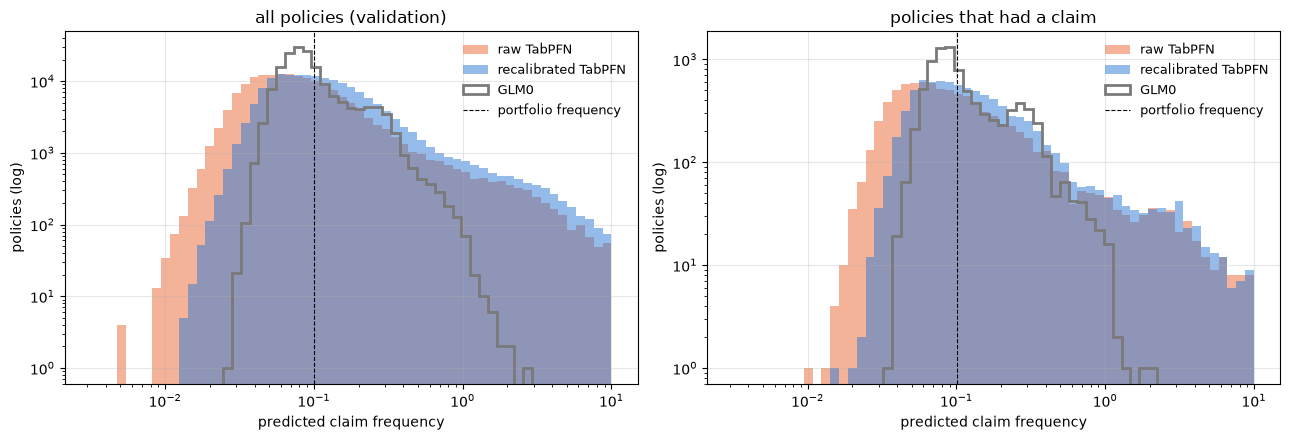

median predicted frequency, claims-only rows:  raw 0.083   recalibrated 0.113   GLM0 0.094


In [6]:
# ============================================================
# 5b. WHAT THE RECALIBRATION DOES: distribution of predicted frequency
# ============================================================
raw_freq = raw_val / validation.Exposure.values
cal_freq = validation.lqm_exp.values / validation.Exposure.values
glm_freq = validation.glm_exp.values / validation.Exposure.values
bins = np.logspace(-2.5, 1, 60)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, mask, title in [(axes[0], np.ones(len(validation), bool), "all policies (validation)"),
                        (axes[1], validation.ClaimNb.values > 0,   "policies that had a claim")]:
    ax.hist(raw_freq[mask], bins=bins, alpha=.5, color=ORANGE, label="raw TabPFN")
    ax.hist(cal_freq[mask], bins=bins, alpha=.5, color=BLUE,   label="recalibrated TabPFN")
    ax.hist(glm_freq[mask], bins=bins, histtype="step", lw=2, color=GREY, label="GLM0")
    ax.axvline(base_rate, color="k", lw=.8, ls="--", label="portfolio frequency")
    ax.set_xscale("log"); ax.set_yscale("log"); ax.set_xlabel("predicted claim frequency"); ax.set_ylabel("policies (log)")
    ax.set_title(title); ax.legend(frameon=False, fontsize=9); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

print(f"median predicted frequency, claims-only rows:  raw {np.median(raw_freq[validation.ClaimNb.values > 0]):.3f}   "
      f"recalibrated {np.median(cal_freq[validation.ClaimNb.values > 0]):.3f}   GLM0 {np.median(glm_freq[validation.ClaimNb.values > 0]):.3f}")

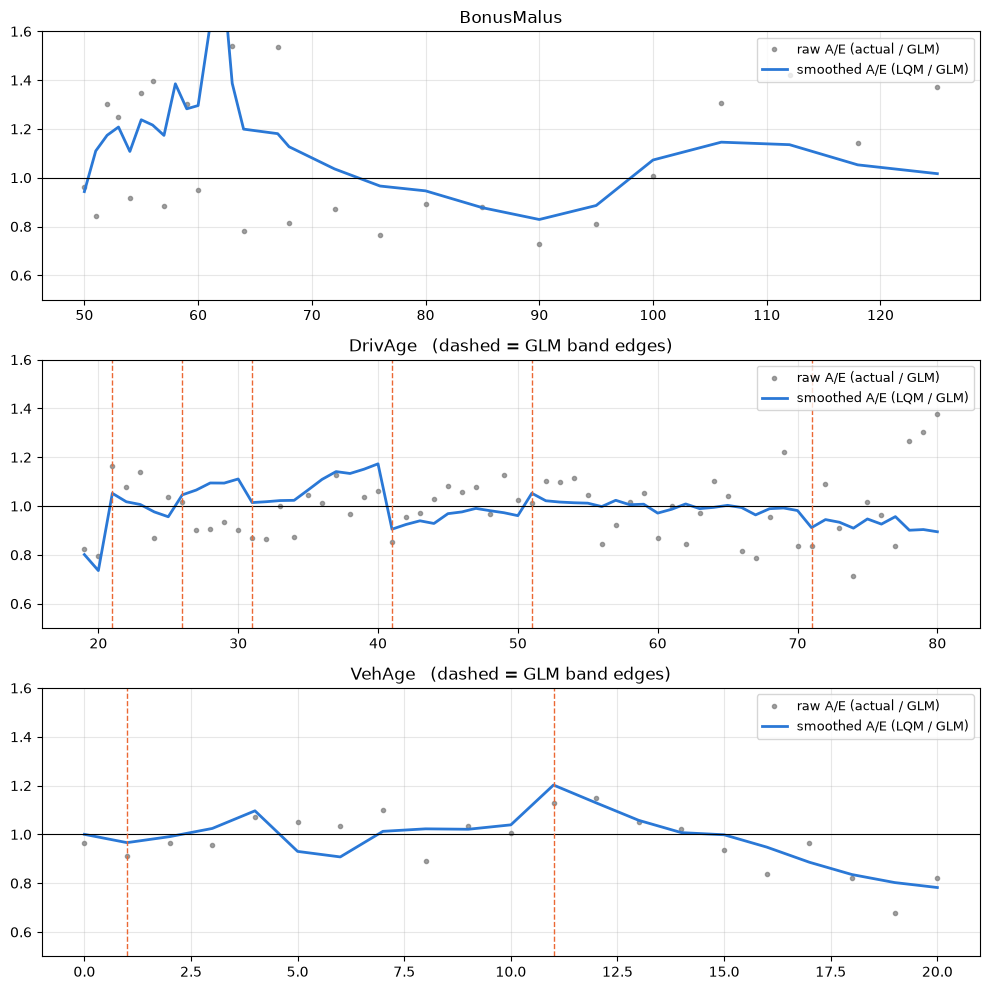

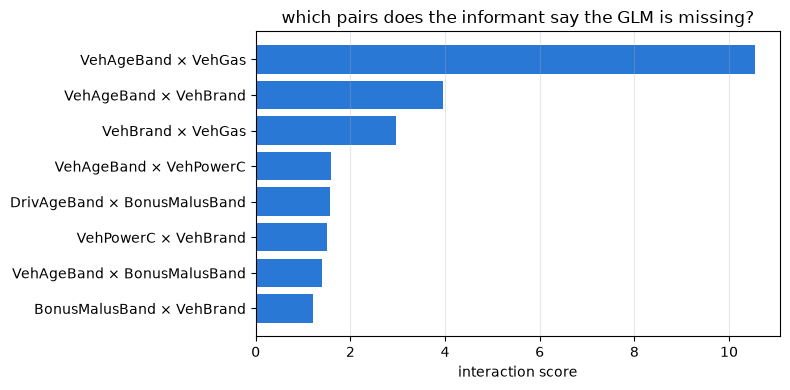

          A              B     score  cells
 VehAgeBand         VehGas 10.548783     20
 VehAgeBand       VehBrand  3.950689     79
   VehBrand         VehGas  2.966529     21
 VehAgeBand      VehPowerC  1.583759     60
DrivAgeBand BonusMalusBand  1.574559     58
  VehPowerC       VehBrand  1.503285     48


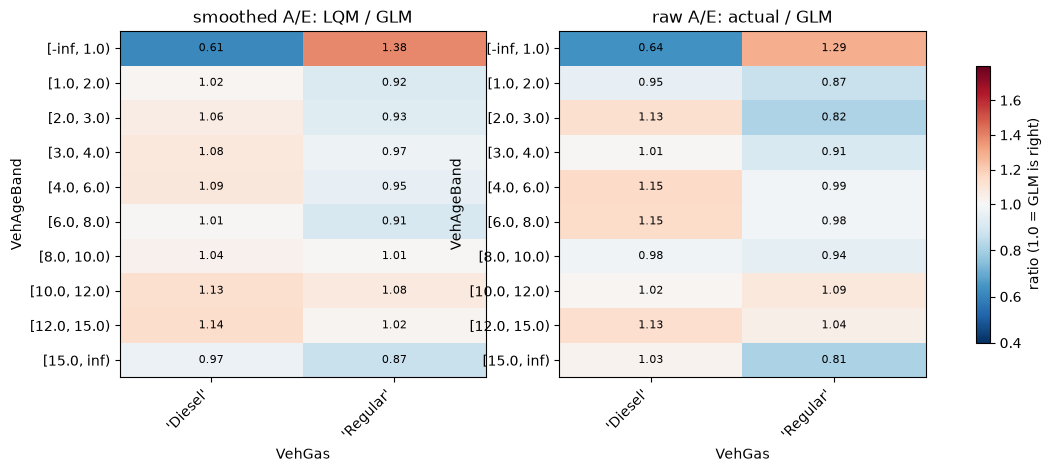

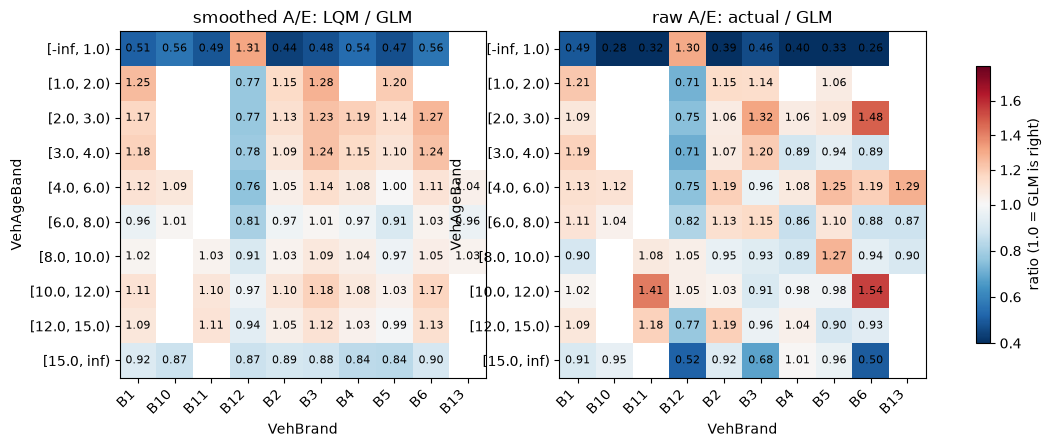

In [7]:
# ============================================================
# 6. THE DIAGNOSTIC: where does the informant disagree with the GLM?
# ============================================================
from matplotlib.colors import TwoSlopeNorm

# diagnostic-only layout bands (not model terms)
validation["BonusMalusBand"] = pd.cut(validation.BonusMalus, [-np.inf, 51, 58, 65, 80, 100, np.inf], right=False)
PAIR_FACTORS = ["DrivAgeBand", "VehAgeBand", "BonusMalusBand", "VehPowerC", "VehBrand", "VehGas", "Region", "AreaN"]

def disagree(cols, part=None, min_glm=30):
    """Per group: actual, GLM-expected, LQM-expected claims; raw A/E and the smoothed (LQM/GLM) version."""
    part = validation if part is None else part
    g = part.groupby(cols, observed=True).agg(exposure=("Exposure", "sum"), actual=("ClaimNb", "sum"),
                                              glm=("glm_exp", "sum"), lqm=("lqm_exp", "sum"))
    g["AE_raw"] = g.actual / g.glm
    g["AE_lqm"] = g.lqm / g.glm
    g["gap"]    = g.lqm - g.glm
    g["z"]      = g.gap / np.sqrt(g.glm)
    return g[g.glm >= min_glm]

def curve(col, edges=None, part=None, ax=None):
    g = disagree(col, part)
    ax = ax or plt.subplots(figsize=(9, 3.2))[1]
    ax.plot(g.index, g.AE_raw, ".", color=GREY, alpha=.7, label="raw A/E (actual / GLM)")
    ax.plot(g.index, g.AE_lqm, "-", color=BLUE, lw=2, label="smoothed A/E (LQM / GLM)")
    ax.axhline(1, color="k", lw=.8)
    if edges is not None:
        for e in edges: ax.axvline(e, color=ORANGE, lw=1, ls="--")
    ax.set_ylim(0.5, 1.6); ax.set_title(col + ("   (dashed = GLM band edges)" if edges is not None else "")); ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=.3)

def interaction_score(a, b, part, min_glm=20):
    """How far the LQM's two-way cells sit from what its two one-way views would predict."""
    g  = disagree([a, b], part, min_glm=0)
    ra = disagree(a, part, min_glm=0).AE_lqm
    rb = disagree(b, part, min_glm=0).AE_lqm
    additive = g.glm.values * ra.loc[g.index.get_level_values(0)].values * rb.loc[g.index.get_level_values(1)].values
    resid, ok = g.lqm.values - additive, g.glm.values >= min_glm
    return (resid[ok] ** 2 / g.glm.values[ok]).mean(), ok.sum()

def scan_interactions(part):
    return pd.DataFrame([(a, b, *interaction_score(a, b, part)) for a, b in combinations(PAIR_FACTORS, 2)],
                        columns=["A", "B", "score", "cells"]).sort_values("score", ascending=False)

def grid_pair(a, b, part=None, min_glm=20):
    g = disagree([a, b], part, min_glm=min_glm)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for ax, col, title in [(axes[0], "AE_lqm", "smoothed A/E: LQM / GLM"), (axes[1], "AE_raw", "raw A/E: actual / GLM")]:
        m = g[col].unstack()
        im = ax.imshow(m.values, cmap="RdBu_r", norm=TwoSlopeNorm(vcenter=1.0, vmin=0.4, vmax=1.8), aspect="auto")
        ax.set_xticks(range(m.shape[1])); ax.set_xticklabels(m.columns, rotation=45, ha="right")
        ax.set_yticks(range(m.shape[0])); ax.set_yticklabels(m.index)
        for i in range(m.shape[0]):
            for j in range(m.shape[1]):
                if not np.isnan(m.values[i, j]): ax.text(j, i, f"{m.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
        ax.set_title(title); ax.set_xlabel(b); ax.set_ylabel(a)
    fig.colorbar(im, ax=axes, shrink=.8, label="ratio (1.0 = GLM is right)"); plt.show()

# ---- (a) one-way: is each factor's shape right? ----
fig, axes = plt.subplots(3, 1, figsize=(10, 10))
curve("BonusMalus", ax=axes[0])
curve("DrivAge", edges=[21, 26, 31, 41, 51, 71], ax=axes[1])
curve("VehAge",  edges=[1, 11],                 ax=axes[2])
plt.tight_layout(); plt.show()

# ---- (b) two-way: which pairs of factors interact? ----
scan = scan_interactions(validation)
fig, ax = plt.subplots(figsize=(8, 4))
top = scan.head(8).iloc[::-1]
ax.barh(top.A + " × " + top.B, top.score, color=BLUE)
ax.set_xlabel("interaction score"); ax.set_title("which pairs does the informant say the GLM is missing?"); ax.grid(axis="x", alpha=.3)
plt.tight_layout(); plt.show()
print(scan.head(6).to_string(index=False))

# ---- (c) the top two pairs, cell by cell, with the raw data alongside ----
grid_pair(scan.iloc[0].A, scan.iloc[0].B)
grid_pair(scan.iloc[1].A, scan.iloc[1].B)

cumulative, scored on test (locked until now):
  GLM0  tutorial spec                  D2 =  5.01%   params = 48
  E1  + bonus-malus banded             D2 =  5.25%   params = 52
  E2  + vehicle age 11+ split          D2 =  5.30%   params = 53
  E3  + driver age 31-40 split         D2 =  5.33%   params = 54
  E4  + B12 own vehicle-age curve      D2 =  6.01%   params = 57
  E5  + vehicle age x fuel             D2 =  6.28%   params = 60

each edit alone, on top of GLM0 (is the gain its own, or borrowed?):
  bonus-malus banded     D2 =  5.25%
  vehicle age split      D2 =  5.06%
  driver age split       D2 =  5.03%
  B12 own curve          D2 =  5.75%
  vehicle age x fuel     D2 =  5.40%

interaction scan against the improved GLM (was 10.5 / 4.0 / 3.0):
             A              B    score  cells
    VehAgeBand BonusMalusBand 1.989729     60
BonusMalusBand       VehBrand 1.468737     50
    VehAgeBand      VehPowerC 1.420988     60
     VehPowerC       VehBrand 1.356632     48


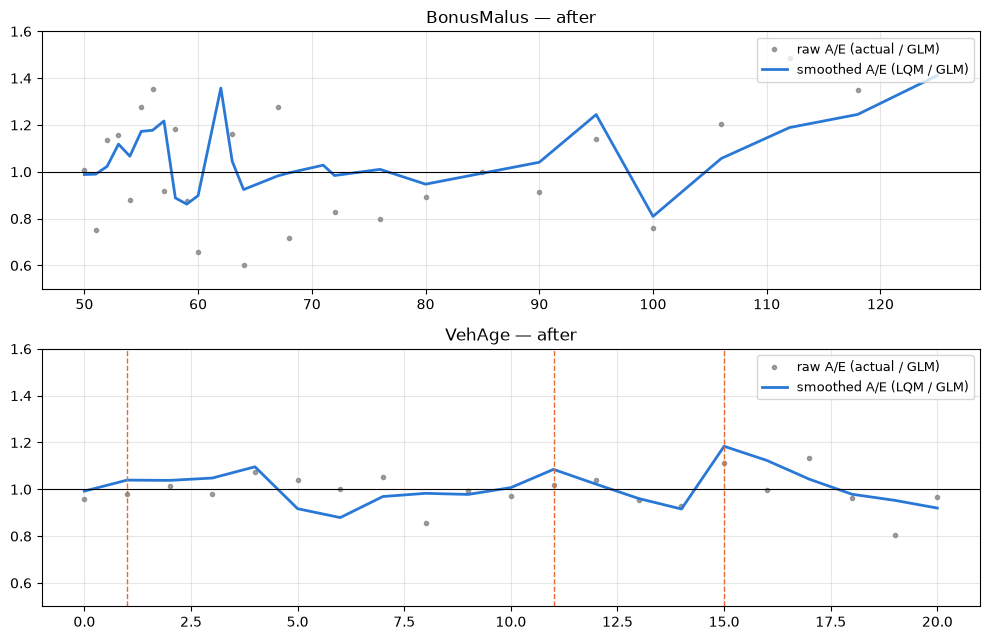

In [9]:
# ============================================================
# 7. RECOMMENDATIONS -> FORMULA EDITS -> VERIFIED ON TEST
# ============================================================
def add_edits(part):
    part = part.copy()
    part["BonusMalusBand"] = pd.cut(part.BonusMalus, [-np.inf, 51, 58, 65, 80, 100, np.inf], right=False)          # E1
    part["VehAgeC2"]  = pd.cut(part.VehAge,  [-np.inf, 1, 11, 15, np.inf], right=False).astype(str)                  # E2: split 11+ at 15
    part["DrivAgeC2"] = pd.cut(part.DrivAge, [-np.inf, 21, 26, 31, 36, 41, 51, 71, np.inf], right=False).astype(str) # E3: split 31-40 at 36
    part["VehBrandX"] = part.VehBrand.astype(str).replace({"B12": "B1"})                                             # E4: B12 leaves the brand factor...
    part["VehAgeB12"] = np.where(part.VehBrand == "B12", part.VehAgeC2, "other")                                      #     ...and gets its own age curve
    return part
train, validation, test = add_edits(train), add_edits(validation), add_edits(test)

EDITS = [  # (label, formula) — cumulative, in the order the evidence was strongest
    ("GLM0  tutorial spec",            FORMULA0),
    ("E1  + bonus-malus banded",       FORMULA0.replace("BMcap", "C(BonusMalusBand)")),
    ("E2  + vehicle age 11+ split",    FORMULA0.replace("BMcap", "C(BonusMalusBand)").replace("C(VehAgeC)", "C(VehAgeC2)")),
    ("E3  + driver age 31-40 split",   FORMULA0.replace("BMcap", "C(BonusMalusBand)").replace("C(VehAgeC)", "C(VehAgeC2)").replace("C(DrivAgeC)", "C(DrivAgeC2)")),
]
EDITS.append(("E4  + B12 own vehicle-age curve", EDITS[-1][1].replace("C(VehBrand)", "C(VehBrandX) + C(VehAgeB12)")))
EDITS.append(("E5  + vehicle age x fuel",        EDITS[-1][1] + " + C(VehAgeC2):C(VehGas)"))

print("cumulative, scored on test (locked until now):")
models = {}
for label, f in EDITS:
    g = fit_glm(f, train); models[label] = g
    print(f"  {label:36s} D2 = {d2(glm_counts(g, test), test):6.2%}   params = {len(g.coef_)}")

print("\neach edit alone, on top of GLM0 (is the gain its own, or borrowed?):")
solo = [("bonus-malus banded",  FORMULA0.replace("BMcap", "C(BonusMalusBand)")),
        ("vehicle age split",   FORMULA0.replace("C(VehAgeC)", "C(VehAgeC2)")),
        ("driver age split",    FORMULA0.replace("C(DrivAgeC)", "C(DrivAgeC2)")),
        ("B12 own curve",       FORMULA0.replace("C(VehBrand)", "C(VehBrandX) + C(VehAgeB12)").replace("C(VehAgeC)", "C(VehAgeC2)")),
        ("vehicle age x fuel",  FORMULA0 + " + C(VehAgeC):C(VehGas)")]
for label, f in solo:
    print(f"  {label:22s} D2 = {d2(glm_counts(fit_glm(f, train), test), test):6.2%}")

FORMULA_FINAL, glm_final = EDITS[-1][1], models[EDITS[-1][0]]

# ---- run the diagnostic again against the improved GLM: has it gone quiet? ----
validation["glm_exp"] = glm_counts(glm_final, validation)
scan_after = scan_interactions(validation)
print("\ninteraction scan against the improved GLM (was 10.5 / 4.0 / 3.0):")
print(scan_after.head(4).to_string(index=False))
fig, axes = plt.subplots(2, 1, figsize=(10, 6.5))
curve("BonusMalus", ax=axes[0]); axes[0].set_title("BonusMalus — after")
curve("VehAge", edges=[1, 11, 15], ax=axes[1]); axes[1].set_title("VehAge — after")
plt.tight_layout(); plt.show()
validation["glm_exp"] = glm_counts(glm0, validation)      # restore GLM0's view for later cells

In [10]:
# ============================================================
# 8. GROUPING CATEGORICAL FACTORS BY THE INFORMANT'S VIEW
# ============================================================
from sklearn.cluster import KMeans

def level_table(col, part=None):
    """Per level: exposure, claims, and the relativity to portfolio average under GLM, LQM and actual."""
    part = validation if part is None else part
    grp = part.groupby(part[col].astype(str))
    ov = {"glm": part.glm_exp.sum(), "lqm": part.lqm_exp.sum(), "act": part.ClaimNb.sum()}
    E = grp.Exposure.sum()
    return pd.DataFrame({"exposure": E, "claims": grp.ClaimNb.sum(),
                         "glm_rel": (grp.glm_exp.sum() / E) / (ov["glm"] / part.Exposure.sum()),
                         "lqm_rel": (grp.lqm_exp.sum() / E) / (ov["lqm"] / part.Exposure.sum()),
                         "actual_rel": (grp.ClaimNb.sum() / E) / (ov["act"] / part.Exposure.sum())}).sort_values("lqm_rel")

def group_levels(col, k, part=None):
    t = level_table(col, part)
    km = KMeans(n_clusters=k, n_init=20, random_state=0).fit(np.log(t.lqm_rel.values).reshape(-1, 1), sample_weight=t.exposure.values)
    order = np.argsort(km.cluster_centers_.ravel())
    t["group"] = [f"G{np.where(order == c)[0][0] + 1}" for c in km.labels_]
    return t

validation["glm_exp"] = glm_counts(glm_final, validation)       # group against the improved GLM
tR = group_levels("Region", 5);     print(tR.round(3), "\n")
tB = group_levels("VehBrandX", 2);  print(tB.round(3))
validation["glm_exp"] = glm_counts(glm0, validation)

def with_groups(part):
    part = part.copy()
    part["RegionG"]    = part.Region.astype(str).map(tR.group)
    part["VehBrandXG"] = part.VehBrandX.astype(str).map(tB.group)
    return part
train, validation, test = with_groups(train), with_groups(validation), with_groups(test)

FORMULA_GROUPED = FORMULA_FINAL.replace("C(Region)", "C(RegionG)").replace("C(VehBrandX)", "C(VehBrandXG)")
glm_grouped = fit_glm(FORMULA_GROUPED, train)
print(f"\n{'final GLM':34s} D2 on test = {d2(glm_counts(glm_final, test), test):.2%}   params = {len(glm_final.coef_)}")
print(f"{'final GLM, Region 5 + Brand 2':34s} D2 on test = {d2(glm_counts(glm_grouped, test), test):.2%}   params = {len(glm_grouped.coef_)}")

         exposure  claims  glm_rel  lqm_rel  actual_rel group
Region                                                       
R41      1996.025     148    0.737    0.769       0.740    G1
R52      5641.196     513    0.892    0.836       0.907    G1
R53      6959.136     686    0.925    0.867       0.983    G2
R24     25783.907    2365    0.885    0.897       0.915    G2
R42       285.361      30    1.111    0.952       1.049    G2
R43       146.485      14    0.765    0.962       0.953    G2
R54      2848.413     242    0.886    0.989       0.847    G3
R74       590.227      52    1.127    1.011       0.879    G3
R83       592.456      51    0.878    1.015       0.859    G3
R25      1642.930     130    1.009    1.019       0.789    G3
R93      8753.589     987    1.048    1.020       1.125    G3
R91      3641.745     386    1.052    1.020       1.057    G3
R82     11310.660    1238    1.120    1.064       1.092    G3
R72      3611.524     304    0.950    1.070       0.840    G3
R26     

mean model                         D2  0.00%   Gini -0.011   deviance 0.3261   predicted   7209  (actual 7179)
GLM0   tutorial spec (48 p.)       D2  5.01%   Gini 0.276   deviance 0.3098   predicted   7253  (actual 7179)
GLM+   5 edits (60 p.)             D2  6.28%   Gini 0.299   deviance 0.3056   predicted   7244  (actual 7179)
GLM++  edits + groupings (35 p.)   D2  6.23%   Gini 0.297   deviance 0.3058   predicted   7240  (actual 7179)
GBM    ceiling                     D2  8.19%   Gini 0.325   deviance 0.2994   predicted   7224  (actual 7179)

GLM++ over GLM0 on test: +1.22 D2 points, 95% interval [0.95, 1.45]


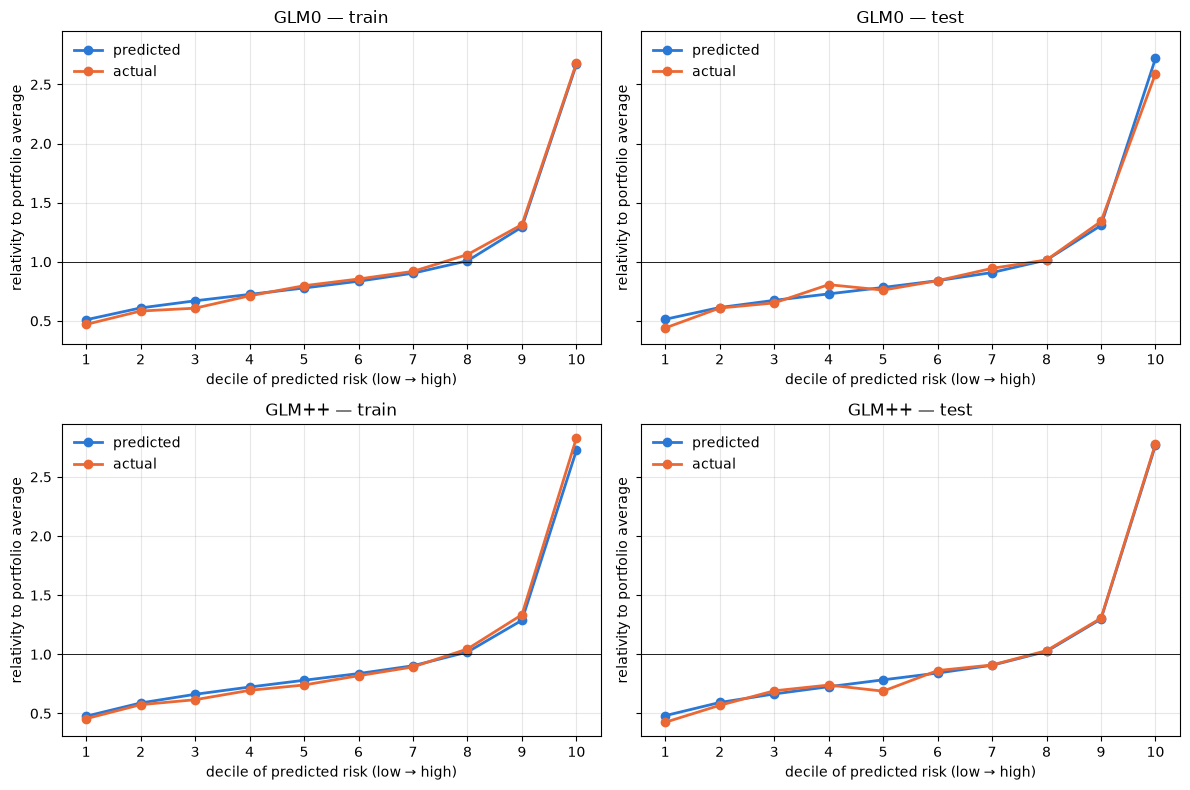

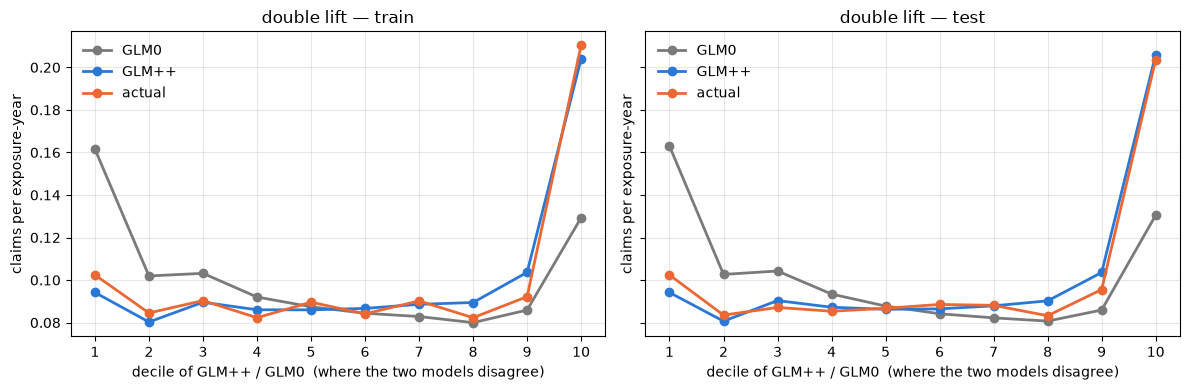

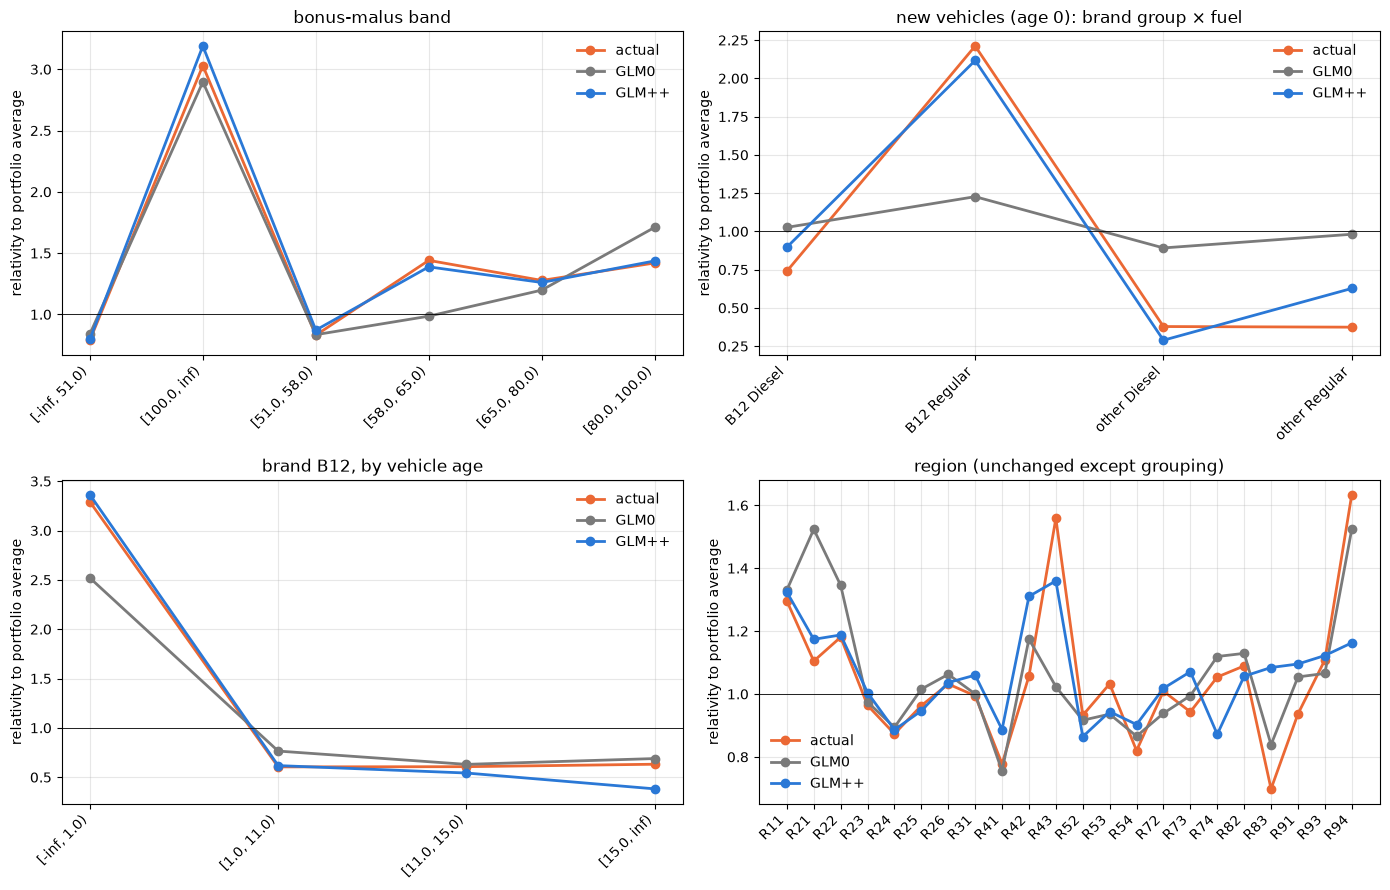

                               GLM0  GLM++  actual
factor         level                              
DrivAgeC2      [-inf, 21.0)   2.599  2.594   2.489
               [21.0, 26.0)   1.587  1.576   1.559
               [26.0, 31.0)   1.067  1.060   1.084
               [31.0, 36.0)   0.958  0.892   0.862
               [36.0, 41.0)   0.846  0.905   0.887
               [41.0, 51.0)   1.026  1.033   1.042
               [51.0, 71.0)   0.936  0.935   0.945
               [71.0, inf)    0.976  0.971   0.968
VehAgeC2       [-inf, 1.0)    3.139  3.135   3.049
               [1.0, 11.0)    0.945  0.945   0.943
               [11.0, 15.0)   0.779  0.860   0.871
               [15.0, inf)    0.781  0.662   0.687
BonusMalusBand [-inf, 51.0)   0.831  0.789   0.789
               [100.0, inf)   2.867  3.163   3.030
               [51.0, 58.0)   0.826  0.864   0.830
               [58.0, 65.0)   0.975  1.376   1.441
               [65.0, 80.0)   1.186  1.250   1.277
               [80.0, 100.0)  1

In [11]:
# ============================================================
# 9. RESULTS: final table, bootstrap, lift charts, relativities
# ============================================================
preds_test = {
    "mean model":                       test.Exposure.values * base_rate,
    "GLM0   tutorial spec (48 p.)":     glm_counts(glm0, test),
    "GLM+   5 edits (60 p.)":           glm_counts(glm_final, test),
    "GLM++  edits + groupings (35 p.)": glm_counts(glm_grouped, test),
    "GBM    ceiling":                   gbm_counts(test),
}
for name, c in preds_test.items(): report(name, c)
m, lo, hi = paired_bootstrap(preds_test["GLM0   tutorial spec (48 p.)"], preds_test["GLM++  edits + groupings (35 p.)"], test)
print(f"\nGLM++ over GLM0 on test: +{m:.2f} D2 points, 95% interval [{lo:.2f}, {hi:.2f}]")

# ---- lift charts (relativity axis) and double lift ----
def lift_table(counts, part, n_bins=10):
    d = pd.DataFrame({"pred": np.asarray(counts), "y": part.ClaimNb.values, "w": part.Exposure.values})
    d = d.iloc[np.argsort(d.pred / d.w, kind="stable")]
    d["bin"] = np.minimum((d.w.cumsum() / d.w.sum() * n_bins).astype(int), n_bins - 1)
    g, base = d.groupby("bin").sum(), d.y.sum() / d.w.sum()
    return pd.DataFrame({"predicted": g.pred / g.w / base, "actual": g.y / g.w / base})

def lift_chart(ax, counts, part, title):
    t, x = lift_table(counts, part), np.arange(1, 11)
    ax.plot(x, t.predicted, "-o", color=BLUE, lw=2, ms=6, label="predicted")
    ax.plot(x, t.actual, "-o", color=ORANGE, lw=2, ms=6, label="actual")
    ax.axhline(1, color="k", lw=.6); ax.set_xticks(x); ax.grid(alpha=.3); ax.legend(frameon=False)
    ax.set_title(title); ax.set_xlabel("decile of predicted risk (low → high)"); ax.set_ylabel("relativity to portfolio average")

def double_lift(ax, a, b, part, title, n_bins=10):
    a, b = np.asarray(a), np.asarray(b)
    d = pd.DataFrame({"a": a, "b": b, "y": part.ClaimNb.values, "w": part.Exposure.values, "r": b / a}).sort_values("r")
    d["bin"] = np.minimum((d.w.cumsum() / d.w.sum() * n_bins).astype(int), n_bins - 1)
    g, x = d.groupby("bin").sum(), np.arange(1, n_bins + 1)
    ax.plot(x, g.a / g.w, "-o", color=GREY,   lw=2, ms=6, label="GLM0")
    ax.plot(x, g.b / g.w, "-o", color=BLUE,   lw=2, ms=6, label="GLM++")
    ax.plot(x, g.y / g.w, "-o", color=ORANGE, lw=2, ms=6, label="actual")
    ax.set_title(title); ax.set_xlabel("decile of GLM++ / GLM0  (where the two models disagree)"); ax.set_ylabel("claims per exposure-year")
    ax.set_xticks(x); ax.grid(alpha=.3); ax.legend(frameon=False)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharey=True)
lift_chart(axes[0, 0], glm_counts(glm0, train),        train, "GLM0 — train")
lift_chart(axes[0, 1], glm_counts(glm0, test),         test,  "GLM0 — test")
lift_chart(axes[1, 0], glm_counts(glm_grouped, train), train, "GLM++ — train")
lift_chart(axes[1, 1], glm_counts(glm_grouped, test),  test,  "GLM++ — test")
plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
double_lift(axes[0], glm_counts(glm0, train), glm_counts(glm_grouped, train), train, "double lift — train")
double_lift(axes[1], glm_counts(glm0, test),  glm_counts(glm_grouped, test),  test,  "double lift — test")
plt.tight_layout(); plt.show()

# ---- variable lift on the factors we changed, plus one we didn't ----
def variable_lift(ax, key, part, preds, title):
    key = pd.Series(key, index=part.index).astype(str)
    w, overall = part.groupby(key).Exposure.sum(), part.ClaimNb.sum() / part.Exposure.sum()
    x = np.arange(len(w))
    ax.plot(x, (part.groupby(key).ClaimNb.sum() / w / overall).values, "-o", color=ORANGE, lw=2, ms=6, label="actual")
    for name, c, colr in [("GLM0", preds[0], GREY), ("GLM++", preds[1], BLUE)]:
        ax.plot(x, (pd.Series(np.asarray(c), index=part.index).groupby(key).sum() / w / overall).values, "-o", color=colr, lw=2, ms=6, label=name)
    ax.set_xticks(x); ax.set_xticklabels(w.index, rotation=45, ha="right"); ax.axhline(1, color="k", lw=.6)
    ax.grid(alpha=.3); ax.legend(frameon=False); ax.set_title(title); ax.set_ylabel("relativity to portfolio average")

P = (glm_counts(glm0, test), glm_counts(glm_grouped, test))
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
variable_lift(axes[0, 0], test.BonusMalusBand, test, P, "bonus-malus band")
new = test.VehAge < 1
variable_lift(axes[0, 1], np.where(test.VehBrand == "B12", "B12 ", "other ") + test.VehGas.astype(str).str.strip("'"), test[new],
              (P[0][new.values], P[1][new.values]), "new vehicles (age 0): brand group × fuel")
b12 = test.VehBrand == "B12"
variable_lift(axes[1, 0], test.VehAgeC2, test[b12], (P[0][b12.values], P[1][b12.values]), "brand B12, by vehicle age")
variable_lift(axes[1, 1], test.Region, test, P, "region (unchanged except grouping)")
plt.tight_layout(); plt.show()

# ---- fitted relativities on test: three columns on the '1.0 = average' scale ----
def fitted_relativities(counts, part, cols):
    p = pd.Series(np.asarray(counts), index=part.index); overall = p.sum() / part.Exposure.sum()
    return pd.concat({c: (p.groupby(part[c].astype(str)).sum() / part.groupby(part[c].astype(str)).Exposure.sum()) / overall for c in cols},
                     names=["factor", "level"])
cols = ["DrivAgeC2", "VehAgeC2", "BonusMalusBand", "VehGas", "VehPowerC", "RegionG", "VehBrandXG", "VehAgeB12"]
rel = pd.concat([fitted_relativities(P[0], test, cols).rename("GLM0"), fitted_relativities(P[1], test, cols).rename("GLM++"),
                 fitted_relativities(test.ClaimNb.values, test, cols).rename("actual")], axis=1).round(3)
pd.set_option("display.max_rows", 200); print(rel)

LQM (100k context, seed 0):    VehAgeBand × VehGas (10.5) | VehAgeBand × VehBrand (4.0) | VehBrand × VehGas (3.0)
GBM as informant:              VehAgeBand × VehGas (8.2) | VehAgeBand × VehBrand (3.0) | VehBrand × VehGas (2.1)
LQM (100k context, seed 1):    VehAgeBand × VehGas (13.8) | VehAgeBand × VehBrand (6.0) | VehBrand × VehGas (3.9)    [D2 10.49%]


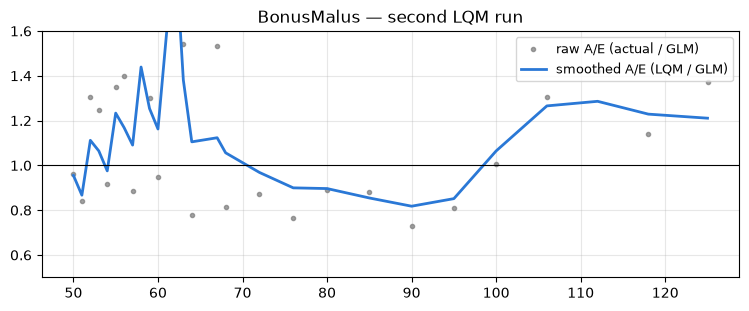

In [12]:
# ============================================================
# 10. ROBUSTNESS: does the diagnosis depend on the informant?
# ============================================================
def top_pairs(part, n=3):
    s = scan_interactions(part).head(n)
    return " | ".join(f"{a} × {b} ({v:.1f})" for a, b, v in zip(s.A, s.B, s.score))

validation["glm_exp"] = glm_counts(glm0, validation)
print("LQM (100k context, seed 0):   ", top_pairs(validation))

# (a) a GBM in the informant's seat: same inputs as the LQM (exposure as a feature)
gbm_x = HistGradientBoostingRegressor(loss="poisson", max_iter=300, learning_rate=0.05, categorical_features="from_dtype", random_state=0)
gbm_x.fit(train[FACTORS + ["Exposure"]], train.ClaimNb)
v = validation.copy(); v["lqm_exp"] = gbm_x.predict(v[FACTORS + ["Exposure"]])
print("GBM as informant:             ", top_pairs(v))

# (b) a second LQM: different context sample and seed (cached after the first run, ~25 min)
CACHE_B = "lqm_raw_validation_seed1.parquet"
if os.path.exists(CACHE_B):
    raw_val_b = pd.read_parquet(CACHE_B).loc[validation.index, "raw"].values
else:
    ctx_b = train.groupby(train.ClaimNb > 0, group_keys=False).sample(frac=100_000 / len(train), random_state=1)
    m_b = TabPFNClassifier(device="cuda", random_state=1, fit_mode="fit_with_cache", n_estimators=4)
    m_b.fit(lqm_inputs(ctx_b), np.minimum(ctx_b.ClaimNb.values, 2))
    k2_b = ctx_b.loc[ctx_b.ClaimNb >= 2, "ClaimNb"].mean()
    X = lqm_inputs(validation)
    P = np.vstack([m_b.predict_proba(X.iloc[i:i + 5000]) for i in range(0, len(X), 5000)])
    raw_val_b = P[:, 1] + k2_b * P[:, 2]
    pd.DataFrame({"raw": raw_val_b}, index=validation.index).to_parquet(CACHE_B)
lvl_b = validation.ClaimNb.sum() / raw_val_b.sum()                 # level-only here; the ranking is what we're checking
v = validation.copy(); v["lqm_exp"] = lvl_b * raw_val_b
print("LQM (100k context, seed 1):   ", top_pairs(v), f"   [D2 {d2(v.lqm_exp.values, v):.2%}]")
fig, ax = plt.subplots(figsize=(9, 3.2)); curve("BonusMalus", part=v, ax=ax); ax.set_title("BonusMalus — second LQM run"); plt.show()

# (c) optional: what if the whole book were small? (reuses nothing expensive; ~2 min per size)